<a href="https://colab.research.google.com/github/mitkrieg/dl-assignment-1/blob/main/ANN_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_fscore_support, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.utils import shuffle

In [3]:
# Load the dataset
from google.colab import files
uploaded = files.upload()  # Manually upload 'Loan.csv'

# Load the dataset
loan = pd.read_csv('Loan.csv')
print(loan.head())
# Check data types and non-null counts per column
print(loan.info())
# Obtain statistics for numerical features
print(loan.describe())

# Step 1: Handle Missing Values (if any)
print("Missing values before handling:")
# Check for missing values to identify any columns with missing entries
print(loan.isnull().sum())

# No Missing Values

Saving Loan.csv to Loan.csv
  ApplicationDate  Age  AnnualIncome  CreditScore EmploymentStatus  \
0      2018-01-01   45         39948          617         Employed   
1      2018-01-02   38         39709          628         Employed   
2      2018-01-03   47         40724          570         Employed   
3      2018-01-04   58         69084          545         Employed   
4      2018-01-05   37        103264          594         Employed   

  EducationLevel  Experience  LoanAmount  LoanDuration MaritalStatus  ...  \
0         Master          22       13152            48       Married  ...   
1      Associate          15       26045            48        Single  ...   
2       Bachelor          26       17627            36       Married  ...   
3    High School          34       37898            96        Single  ...   
4      Associate          17        9184            36       Married  ...   

   MonthlyIncome UtilityBillsPaymentHistory  JobTenure  NetWorth  \
0    3329.000000    

In [4]:
# Step 2: Define Features (X) and Target Variable (y)
X = loan.drop(columns=['LoanApproved'])  # Features
y = loan['LoanApproved']  # Target variable

In [5]:
# Step 3: Log Transformation for Positively Skewed Numerical (Continuous Features)

# Identify numerical features in X (excluding target)
numerical_features = X.select_dtypes(include=[np.number]).columns
print(numerical_features)

# List to store features for log transformation based on skewness
features_for_log_transformation = []

# Identify features with positive skewness
for col in numerical_features:
    if X[col].skew() > 1:  # Positive skewness threshold
        features_for_log_transformation.append(col)

# Apply log transformation to positively skewed features
for col in features_for_log_transformation:
    X[f'log_{col}'] = np.log1p(X[col])  # Log transformation using log1p (handles 0 values safely)

# Print transformed features for verification
print("Features for log transformation:")
print(features_for_log_transformation)
print(X.head())

Index(['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount',
       'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments',
       'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
       'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory',
       'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory',
       'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets',
       'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory',
       'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate',
       'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'RiskScore'],
      dtype='object')
Features for log transformation:
['AnnualIncome', 'LoanAmount', 'MonthlyDebtPayments', 'NumberOfCreditInquiries', 'BankruptcyHistory', 'PreviousLoanDefaults', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'NetWorth', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio']
  ApplicationDate 

In [6]:
# Identify all categorical features
categorical_features = X.select_dtypes(include=['object']).columns
print(categorical_features)
# Inspect the unique values of each column
for col in categorical_features:
    print(f"Unique values in '{col}':")
    print(loan[col].unique())
    print("-" * 40)

Index(['ApplicationDate', 'EmploymentStatus', 'EducationLevel',
       'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose'],
      dtype='object')
Unique values in 'ApplicationDate':
['2018-01-01' '2018-01-02' '2018-01-03' ... '2072-10-01' '2072-10-02'
 '2072-10-03']
----------------------------------------
Unique values in 'EmploymentStatus':
['Employed' 'Self-Employed' 'Unemployed']
----------------------------------------
Unique values in 'EducationLevel':
['Master' 'Associate' 'Bachelor' 'High School' 'Doctorate']
----------------------------------------
Unique values in 'MaritalStatus':
['Married' 'Single' 'Divorced' 'Widowed']
----------------------------------------
Unique values in 'HomeOwnershipStatus':
['Own' 'Mortgage' 'Rent' 'Other']
----------------------------------------
Unique values in 'LoanPurpose':
['Home' 'Debt Consolidation' 'Education' 'Other' 'Auto']
----------------------------------------


In [7]:
# Drop ApplicationDate from the dataset
X = X.drop(columns=['ApplicationDate'], axis=1)

# Identify all categorical features (excluding ApplicationDate)
categorical_features = X.select_dtypes(include=['object']).columns
print("Categorical features to be one-hot encoded:")
print(categorical_features)

# Inspect the unique values of each categorical feature
for col in categorical_features:
    print(f"Unique values in '{col}':")
    print(X[col].unique())
    print("-" * 40)

# Apply one-hot encoding to categorical features with more than two unique values
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Check the updated dataset
print("Data after one-hot encoding:")
print(X.head())

Categorical features to be one-hot encoded:
Index(['EmploymentStatus', 'EducationLevel', 'MaritalStatus',
       'HomeOwnershipStatus', 'LoanPurpose'],
      dtype='object')
Unique values in 'EmploymentStatus':
['Employed' 'Self-Employed' 'Unemployed']
----------------------------------------
Unique values in 'EducationLevel':
['Master' 'Associate' 'Bachelor' 'High School' 'Doctorate']
----------------------------------------
Unique values in 'MaritalStatus':
['Married' 'Single' 'Divorced' 'Widowed']
----------------------------------------
Unique values in 'HomeOwnershipStatus':
['Own' 'Mortgage' 'Rent' 'Other']
----------------------------------------
Unique values in 'LoanPurpose':
['Home' 'Debt Consolidation' 'Education' 'Other' 'Auto']
----------------------------------------
Data after one-hot encoding:
   Age  AnnualIncome  CreditScore  Experience  LoanAmount  LoanDuration  \
0   45         39948          617          22       13152            48   
1   38         39709         

In [8]:
print(X.dtypes)

Age                                 int64
AnnualIncome                        int64
CreditScore                         int64
Experience                          int64
LoanAmount                          int64
LoanDuration                        int64
NumberOfDependents                  int64
MonthlyDebtPayments                 int64
CreditCardUtilizationRate         float64
NumberOfOpenCreditLines             int64
NumberOfCreditInquiries             int64
DebtToIncomeRatio                 float64
BankruptcyHistory                   int64
PreviousLoanDefaults                int64
PaymentHistory                      int64
LengthOfCreditHistory               int64
SavingsAccountBalance               int64
CheckingAccountBalance              int64
TotalAssets                         int64
TotalLiabilities                    int64
MonthlyIncome                     float64
UtilityBillsPaymentHistory        float64
JobTenure                           int64
NetWorth                          

In [9]:
# Convert boolean columns to integers (0 or 1)
X = X.astype({col: 'int' for col in X.select_dtypes(include=['bool']).columns})

# Check the updated dataset
print("Updated dataset after converting boolean columns to integers:")
print(X.head())

Updated dataset after converting boolean columns to integers:
   Age  AnnualIncome  CreditScore  Experience  LoanAmount  LoanDuration  \
0   45         39948          617          22       13152            48   
1   38         39709          628          15       26045            48   
2   47         40724          570          26       17627            36   
3   58         69084          545          34       37898            96   
4   37        103264          594          17        9184            36   

   NumberOfDependents  MonthlyDebtPayments  CreditCardUtilizationRate  \
0                   2                  183                   0.354418   
1                   1                  496                   0.087827   
2                   2                  902                   0.137414   
3                   1                  755                   0.267587   
4                   1                  274                   0.320535   

   NumberOfOpenCreditLines  ...  MaritalStatus_M

In [ ]:
print(X.dtypes)

In [10]:
# Identify numerical features (excluding one-hot-encoded categorical features)
numerical_features = X.select_dtypes(include=['float64', 'int64']).columns

# Exclude one-hot-encoded columns from numerical features
# One-hot-encoded columns typically contain only 0 and 1, so we skip them
non_standardizable_features = [col for col in X.columns if X[col].nunique() == 2]
features_to_standardize = [col for col in numerical_features if col not in non_standardizable_features]

# Print the features to be standardized and not standardized
print("Features to Standardize:")
print(features_to_standardize)
print("\nFeatures Not to Standardize (e.g., one-hot encoded):")
print(non_standardizable_features)

# Apply standardization only to the selected features
scaler = StandardScaler()
X[features_to_standardize] = scaler.fit_transform(X[features_to_standardize])

# Check the standardized features
print("Dataset after standardization:")
print(X.head())

Features to Standardize:
['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'RiskScore', 'log_AnnualIncome', 'log_LoanAmount', 'log_MonthlyDebtPayments', 'log_NumberOfCreditInquiries', 'log_SavingsAccountBalance', 'log_CheckingAccountBalance', 'log_TotalAssets', 'log_TotalLiabilities', 'log_MonthlyIncome', 'log_NetWorth', 'log_MonthlyLoanPayment', 'log_TotalDebtToIncomeRatio']

Features Not to Standardize (e.g., one-hot encoded):
['BankruptcyHistory', 'PreviousLoanDefaults', 'log_BankruptcyHistory', 'log_PreviousLoanDefaults', '

In [11]:
# Step 1: Split into training and temporary sets (e.g., 70% train, 30% temporary)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Step 2: Split the temporary set into development and test sets (e.g., 15% dev, 15% test)
X_dev, X_test, y_dev, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [12]:
# Verify data shapes
print("Shapes before tensor conversion:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_dev:", X_dev.shape, "y_dev:", y_dev.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

Shapes before tensor conversion:
X_train: (14000, 59) y_train: (14000,)
X_dev: (3000, 59) y_dev: (3000,)
X_test: (3000, 59) y_test: (3000,)


In [13]:
# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_dev_tensor = torch.tensor(X_dev.values, dtype=torch.float32)
y_dev_tensor = torch.tensor(y_dev.values, dtype=torch.long)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# Create TensorDatasets and DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
dev_dataset = TensorDataset(X_dev_tensor, y_dev_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Training set size: {len(train_dataset)}")
print(f"Development set size: {len(dev_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size: 14000
Development set size: 3000
Test set size: 3000


### Build and Train the ANN Model ###

In [14]:
# Define the ANN model
class ANNModel(nn.Module):
    def __init__(self, input_dim):
        super(ANNModel, self).__init__()
        self.hidden1 = nn.Linear(input_dim, 64)
        self.hidden2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 2)  # Binary classification (LoanApproved: 0 or 1)
        self.dropout = nn.Dropout(0.3)  # Dropout to prevent overfitting
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.hidden1(x))
        x = self.dropout(x)
        x = self.relu(self.hidden2(x))
        x = self.dropout(x)
        x = self.output(x)
        return x

# Initialize the model
input_dim = X_train.shape[1]
model = ANNModel(input_dim)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()  # For classification tasks
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)  # L2 regularization with weight_decay

# Check model structure
print(model)


ANNModel(
  (hidden1): Linear(in_features=59, out_features=64, bias=True)
  (hidden2): Linear(in_features=64, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (relu): ReLU()
)


### Train the Model ###

In [15]:
# Training loop
epochs = 50
best_loss = float('inf')
patience = 5  # Early stopping patience
counter = 0

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Calculate validation loss
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in dev_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss /= len(dev_loader)

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # Early stopping
    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
        best_model = model.state_dict()  # Save the best model
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

# Load the best model
model.load_state_dict(best_model)


Epoch 1/50 - Train Loss: 0.1335, Val Loss: 0.0134
Epoch 2/50 - Train Loss: 0.0132, Val Loss: 0.0052
Epoch 3/50 - Train Loss: 0.0076, Val Loss: 0.0059
Epoch 4/50 - Train Loss: 0.0038, Val Loss: 0.0021
Epoch 5/50 - Train Loss: 0.0023, Val Loss: 0.0047
Epoch 6/50 - Train Loss: 0.0030, Val Loss: 0.0057
Epoch 7/50 - Train Loss: 0.0037, Val Loss: 0.0014
Epoch 8/50 - Train Loss: 0.0026, Val Loss: 0.0042
Epoch 9/50 - Train Loss: 0.0022, Val Loss: 0.0036
Epoch 10/50 - Train Loss: 0.0018, Val Loss: 0.0023
Epoch 11/50 - Train Loss: 0.0022, Val Loss: 0.0044
Epoch 12/50 - Train Loss: 0.0021, Val Loss: 0.0022
Early stopping triggered.


<All keys matched successfully>

### Evaluate the Model ###

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2283
           1       1.00      1.00      1.00       717

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

Confusion Matrix:
[[2283    0]
 [   1  716]]
ROC-AUC Score: 1.0000


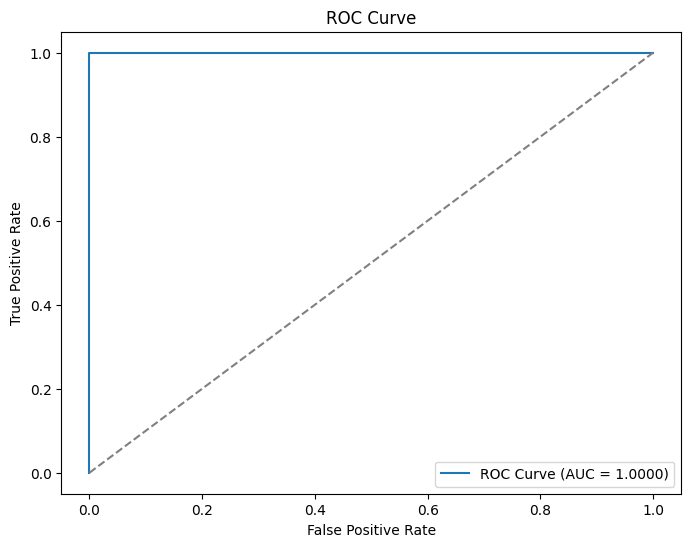

In [16]:
# Evaluation on test set
model.eval()
y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        y_true.extend(y_batch.numpy())
        y_pred.extend(preds.numpy())
        y_prob.extend(probs[:, 1].numpy())

# Classification metrics
print("Classification Report:")
print(classification_report(y_true, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# ROC-AUC
roc_auc = roc_auc_score(y_true, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
